# Customer Intelligence System using Classification, Ensemble Learning and Clustering

### Week 3 Assignment

This project develops an end-to-end Customer Intelligence System by combining supervised and unsupervised machine learning techniques. The system predicts customer behavior using classification models and identifies meaningful customer segments using clustering algorithms to support business decision-making.

## Objective

The objective of this project is to build a Customer Intelligence System that:

- Predicts customer responses using classification models.
- Improves prediction performance using ensemble learning techniques.
- Segments customers into meaningful groups using clustering algorithms.
- Provides actionable business insights for targeted marketing and customer relationship management.

## Dataset Information

This project uses the **Customer Personality Analysis** dataset, which contains customer demographics, purchasing behavior, campaign responses, and spending information.

The dataset includes features such as:

- Customer demographics
- Income
- Education
- Marital status
- Purchase history
- Campaign responses
- Product spending
- Website visits

These features enable both predictive modeling and customer segmentation.

## Why the Dataset is Different

The reference notebook provided from Kaggle uses the **Country Data** dataset and focuses primarily on unsupervised learning techniques such as K-Means, Hierarchical Clustering, and DBSCAN.

For this assignment, the dataset has been changed to a **Customer Personality Analysis** dataset because the objective is to develop a **Customer Intelligence System**.

A customer dataset is more appropriate because it contains customer behavior, purchasing patterns, and campaign response information, allowing the implementation of:

- Classification
- Ensemble Learning (Random Forest and XGBoost)
- Customer Segmentation using Clustering

This makes the project align with the assignment requirements while following similar machine learning concepts demonstrated in the reference notebook.

Import Libraries

In [ ]:
# ==============================
# Customer Intelligence System
# Import Required Libraries
# ==============================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# PCA
from sklearn.decomposition import PCA

## Importing Libraries

This section imports all the required Python libraries used for data analysis, preprocessing, classification, clustering, visualization, and model evaluation.

Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv("marketing_campaign.csv", sep="\t")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Understand Dataset

In [3]:
print("Shape of Dataset")
print(df.shape)

print("\n")

print("Column Names")
print(df.columns)

print("\n")

print("Information")
df.info()

print("\n")

print("Statistical Summary")
df.describe()

Shape of Dataset
(2240, 29)


Column Names
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income     

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


Check Missing Values

In [4]:
# Missing Values

print(df.isnull().sum())

# Duplicate Records

print("\nDuplicate Rows:", df.duplicated().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Duplicate Rows: 0


Data Cleaning

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing Income values
df["Income"] = df["Income"].fillna(df["Income"].median())

# Convert joining date to datetime
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)

print("Cleaning Completed")

Cleaning Completed


## Feature Engineering

In this section, we create new features that provide additional insights into customer behavior and purchasing patterns.

In [7]:
# ==========================
# Feature Engineering
# ==========================

# Total amount spent by each customer
df["Total_Spent"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Total purchases made
df["Total_Purchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

# Customer Age
df["Age"] = 2025 - df["Year_Birth"]

# Family Size
df["Family_Size"] = df["Kidhome"] + df["Teenhome"] + 1

print(df[["Total_Spent", "Total_Purchases", "Age", "Family_Size"]].head())

   Total_Spent  Total_Purchases  Age  Family_Size
0         1617               25   68            1
1           27                6   71            3
2          776               21   60            1
3           53                8   41            2
4          422               19   44            2


## Exploratory Data Analysis

Visualizing customer spending patterns and relationships among important features.

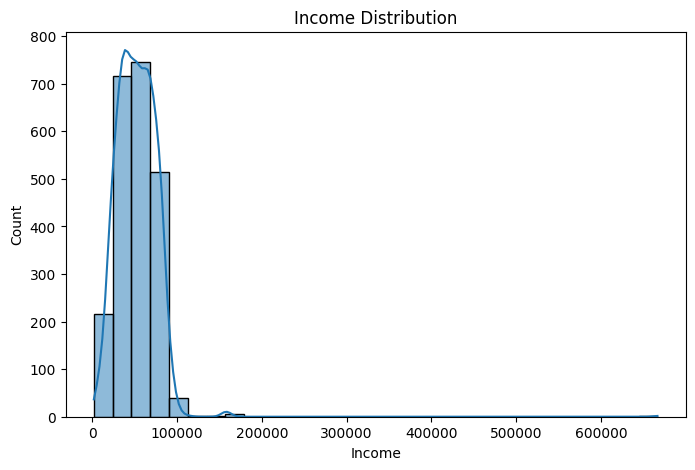

In [8]:
# Distribution of Income

plt.figure(figsize=(8,5))
sns.histplot(df["Income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

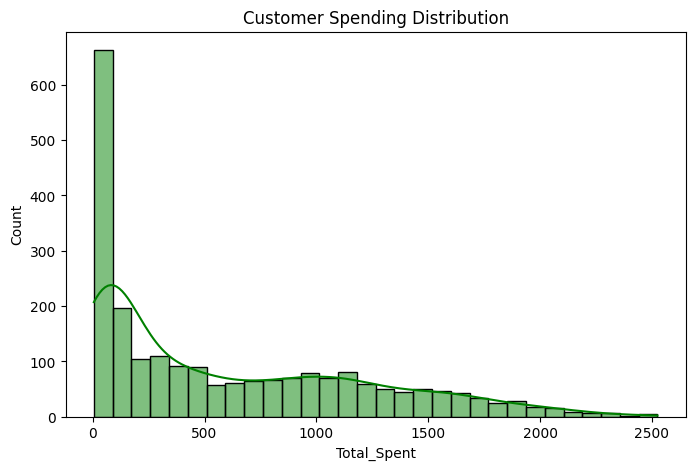

In [9]:
# Total Spending Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Total_Spent"], bins=30, color="green", kde=True)
plt.title("Customer Spending Distribution")
plt.show()

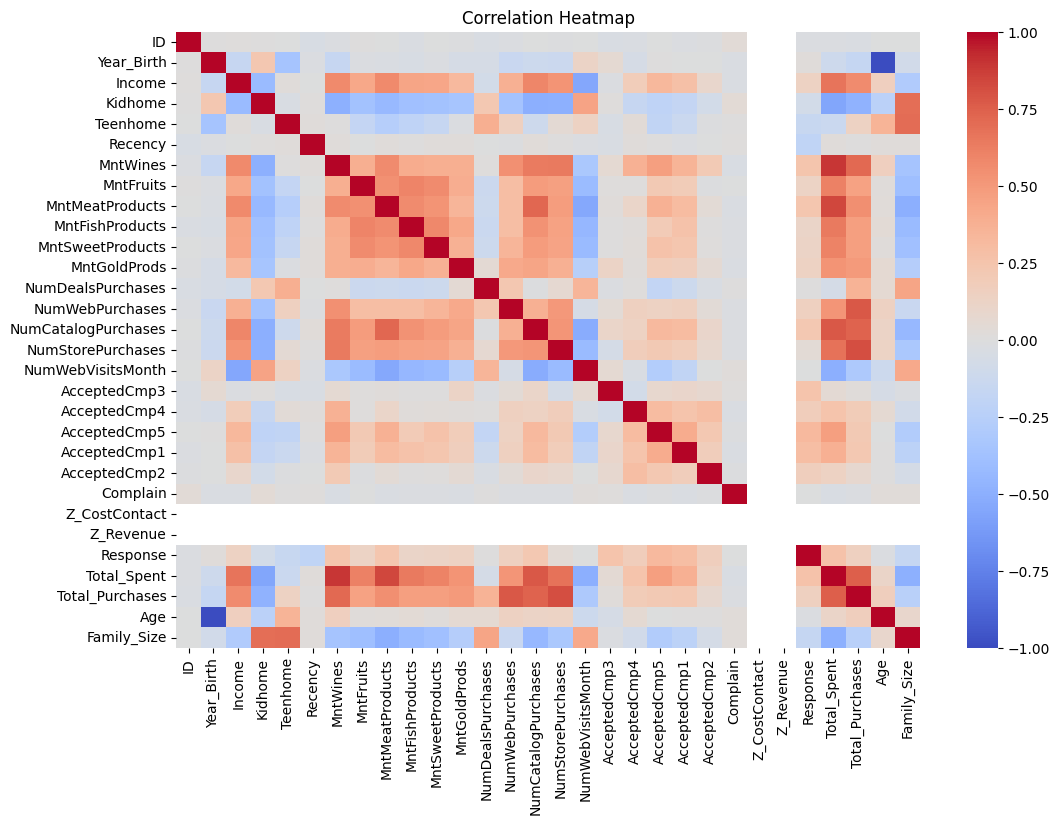

In [10]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Creating Target Variable

Customers with spending greater than the median are classified as High Value Customers.

In [11]:
# Create Target Variable

median_spent = df["Total_Spent"].median()

df["High_Value_Customer"] = np.where(
    df["Total_Spent"] > median_spent,
    1,
    0
)

print(df["High_Value_Customer"].value_counts())

High_Value_Customer
0    1121
1    1119
Name: count, dtype: int64


## Encoding and Scaling

In [12]:
# ======================
# Label Encoding
# ======================

encoder = LabelEncoder()

categorical_columns = [
    "Education",
    "Marital_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Encoding Completed")

Encoding Completed


In [13]:
# Remove unnecessary columns

df.drop(["ID","Dt_Customer"], axis=1, inplace=True)

In [14]:
# Separate Features and Target

X = df.drop("High_Value_Customer", axis=1)

y = df["High_Value_Customer"]

In [15]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

Scaling Completed


## Train-Test Split

In [16]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1792, 31)
(448, 31)


## Random Forest Classification

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [17]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


Evaluate Model

In [18]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9977678571428571
Precision: 1.0
Recall   : 0.9958677685950413
F1 Score : 0.9979296066252588


Classification Report

In [19]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00       242

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



Confusion Matrix

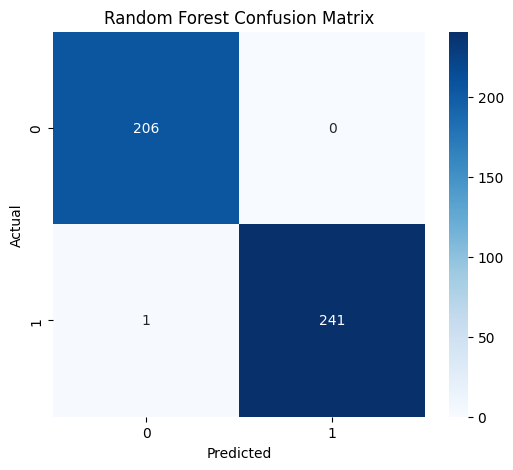

In [20]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()